# Exploratory Data Analysis


--- Audit Sinyal Kimia (NIM 026) ---


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                 Feature           VIF  MI_Score      Decision
19          wine_cluster  4.191612e+00  0.184459  ELITE SIGNAL
16       alc_sulph_inter  2.338704e+03  0.181418  ELITE SIGNAL
10               alcohol  3.237251e+04  0.171789  ELITE SIGNAL
18            alcohol_sq  8.371083e+03  0.153431  ELITE SIGNAL
11       freshness_index           inf  0.128035  ELITE SIGNAL
6   total sulfur dioxide  3.269616e+01  0.118090  ELITE SIGNAL
13               so2_log  3.740211e+02  0.113420  ELITE SIGNAL
9              sulphates  2.249464e+03  0.097008  ELITE SIGNAL
12      so2_active_ratio  4.012001e+01  0.096592  ELITE SIGNAL
1       volatile acidity           inf  0.094079  ELITE SIGNAL
17           vol_acid_sq  5.371116e+01  0.091335  ELITE SIGNAL
2            citric acid           inf  0.056592  ELITE SIGNAL
14       body_complexity  4.769337e+01  0.054917  ELITE SIGNAL
7                density  1.114855e+04  0.050969  ELITE SIGNAL
4              chlorides  7.738485e+00  0.048349     Se

/tmp/ipykernel_17/148484758.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='quality', y='freshness_index', data=df_train, palette='coolwarm')


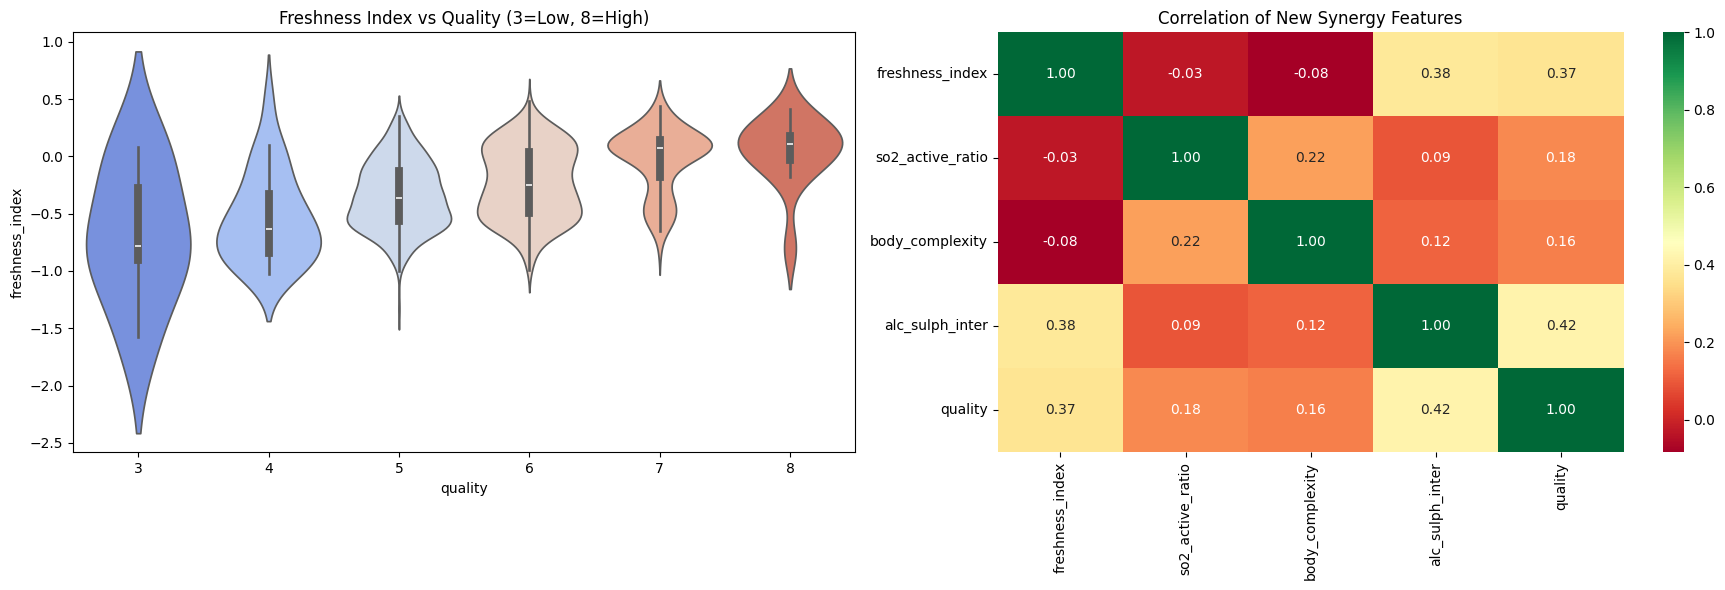


✅ Total Fitur Siap Olah: 20
>>> WARNING: Fitur 'ELITE SIGNAL' dilarang keras dihapus di Tahap Pruning!


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1.1 Memuat Dataset (Kaggle Robust)
train_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_training.csv'
test_path = '/kaggle/input/datasets/dimaspashaakrilian/wine-quality/data_testing.csv'

if not os.path.exists(train_path):
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            if 'data_training' in file: train_path = os.path.join(root, file)
            if 'data_testing' in file: test_path = os.path.join(root, file)

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# 1.2 UPGRADED: High-Fidelity Enology Engineering
# Kita ciptakan fitur yang merepresentasikan "Harmoni" kimiawi wine
for df in [df_train, df_test]:
    # 1. Freshness & Spoilage Index (Asam sitrat itu segar, volatile itu busuk)
    df['freshness_index'] = df['citric acid'] - df['volatile acidity']
    
    # 2. SO2 Protection Efficiency (Rasio SO2 bebas terhadap total menentukan daya simpan)
    df['so2_active_ratio'] = df['free sulfur dioxide'] / (df['total sulfur dioxide'] + 1e-5)
    df['so2_log'] = np.log1p(df['total sulfur dioxide']) # Meredam pencilan sulfur
    
    # 3. Mouthfeel & Body (Interaksi Alkohol, Gula, dan pH)
    df['body_complexity'] = (df['alcohol'] * df['pH']) / (df['residual sugar'] + 1e-5)
    df['sweet_acid_balance'] = df['residual sugar'] / (df['fixed acidity'] + 1e-5)
    
    # 4. Premium Markers (Interaksi yang sering muncul di wine skor 7-8)
    df['alc_sulph_inter'] = df['alcohol'] * df['sulphates']
    df['vol_acid_sq'] = df['volatile acidity'] ** 2
    df['alcohol_sq'] = df['alcohol'] ** 2

# 1.3 Latent Clustering: Isolasi Tipe Wine
# Gunakan 6 cluster untuk menangkap variasi kualitas yang lebih ekstrem
features_for_cluster = ['alcohol', 'volatile acidity', 'total sulfur dioxide', 'pH', 'sulphates']
scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(df_train[features_for_cluster])
kmeans = KMeans(n_clusters=6, random_state=42, n_init=15) 
df_train['wine_cluster'] = kmeans.fit_predict(X_clust)
df_test['wine_cluster'] = kmeans.predict(scaler_clust.transform(df_test[features_for_cluster]))

# 1.4 Diagnostik Sinyal: MI vs VIF
def detailed_audit(df):
    X = df.drop(columns=['Id', 'quality']).select_dtypes(include=[np.number])
    y = df['quality']
    
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    # Menggunakan try-except untuk stabilitas perhitungan VIF
    vifs = []
    for i in range(len(X.columns)):
        try: vifs.append(variance_inflation_factor(X.values, i))
        except: vifs.append(999)
    vif_data["VIF"] = vifs
    
    # Mutual Information: Mendeteksi sinyal non-linear untuk DNN
    vif_data["MI_Score"] = mutual_info_classif(X, y, random_state=42)
    
    # Proteksi: Jika MI > 0.05, fitur ini HARUS lewat ke DNN
    vif_data["Decision"] = np.where(vif_data["MI_Score"] > 0.05, "ELITE SIGNAL", "Secondary")
    return vif_data.sort_values(by="MI_Score", ascending=False)

print("\n--- Audit Sinyal Kimia (NIM 026) ---")
audit_results = detailed_audit(df_train)
print(audit_results)

# 1.5 Visualisasi Distribusi Sinyal Premium
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.violinplot(x='quality', y='freshness_index', data=df_train, palette='coolwarm')
plt.title('Freshness Index vs Quality (3=Low, 8=High)')

plt.subplot(1, 2, 2)
# Korelasi fitur baru terhadap target
new_feats = ['freshness_index', 'so2_active_ratio', 'body_complexity', 'alc_sulph_inter', 'quality']
sns.heatmap(df_train[new_feats].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation of New Synergy Features')

plt.tight_layout()
plt.show()

print(f"\n✅ Total Fitur Siap Olah: {len(df_train.columns) - 2}")
print(">>> WARNING: Fitur 'ELITE SIGNAL' dilarang keras dihapus di Tahap Pruning!")

# Data Preparation

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.cluster import KMeans
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN # Senjata utama pembersih data
import pandas as pd
import numpy as np

# 2.1 Master Feature Engineering (Enology Signal Injection)
def transform_features(df):
    df_new = df.copy()
    
    # 1. Freshness & Spoilage (Sinyal pembeda kualitas ekstrem)
    df_new['freshness_index'] = df_new['citric acid'] - df_new['volatile acidity']
    df_new['so2_active_ratio'] = df_new['free sulfur dioxide'] / (df_new['total sulfur dioxide'] + 1e-5)
    
    # 2. Body & Complexity (Mouthfeel simulation)
    df_new['body_complexity'] = (df_new['alcohol'] * df_new['pH']) / (df_new['residual sugar'] + 1e-5)
    df_new['sugar_log'] = np.log1p(df_new['residual sugar'])
    df_new['so2_log'] = np.log1p(df_new['total sulfur dioxide'])
    
    # 3. Non-Linear Interaction (Deep Learning Fuel)
    df_new['alc_sulph_inter'] = df_new['alcohol'] * df_new['sulphates']
    df_new['alc_vol_inter'] = df_new['alcohol'] * df_new['volatile acidity']
    
    # 4. Polynomials (Curvature signals)
    df_new['alcohol_sq'] = df_new['alcohol'] ** 2
    df_new['vol_acid_sq'] = df_new['volatile acidity'] ** 2
    
    # 5. Mencegah VIF Tak Hingga secara cerdas
    # Kita hapus fitur original yang redundansinya 0.99+, tapi simpan interaksinya
    vif_drop = ['density'] 
    df_new = df_new.drop(columns=[col for col in vif_drop if col in df_new.columns])
    
    return df_new

# Eksekusi Transformasi
df_train_eng = transform_features(df_train)
df_test_eng = transform_features(df_test)

X = df_train_eng.drop(columns=['Id', 'quality'])
y = df_train_eng['quality']
X_test_final = df_test_eng.drop(columns=['Id'])
test_id = df_test_eng['Id']

# 2.2 Robust Capping (Extreme Outlier Protection)
for col in X.columns:
    low, up = X[col].quantile(0.005), X[col].quantile(0.995)
    X[col] = np.clip(X[col], low, up)
    X_test_final[col] = np.clip(X_test_final[col], low, up)

# 2.3 Split Data (Stratified)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2.4 Power Transformation & Scaling (Yeo-Johnson)
pt = PowerTransformer(method='yeo-johnson')
scaler = StandardScaler()

X_train_prepared = pd.DataFrame(scaler.fit_transform(pt.fit_transform(X_train_raw)), columns=X.columns)
X_val_prepared = pd.DataFrame(scaler.transform(pt.transform(X_val_raw)), columns=X.columns)
X_test_prepared = pd.DataFrame(scaler.transform(pt.transform(X_test_final)), columns=X.columns)

# 2.5 Advanced Latent Clustering (6 Clusters)
# Menggunakan 6 cluster untuk menangkap lebih banyak variasi tipe wine
kmeans = KMeans(n_clusters=6, random_state=42, n_init=15)
X_train_prepared['cluster'] = kmeans.fit_predict(X_train_prepared)
X_val_prepared['cluster'] = kmeans.predict(X_val_prepared)
X_test_prepared['cluster'] = kmeans.predict(X_test_prepared)

# 2.6 OOF Soft Labeling (High-Fidelity Teacher)
skf_reg = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
reg_teacher = ExtraTreesRegressor(n_estimators=500, max_depth=15, random_state=42, n_jobs=-1)
y_train_oof = cross_val_predict(reg_teacher, X_train_prepared, y_train, cv=skf_reg)

# 2.7 UPGRADED: SMOTEENN for Clean Volume Expansion
# Target: Membuat dataset yang 'gemuk' tapi bersih di perbatasan kelas
strategy = {3: 500, 4: 600, 5: 800, 6: 800, 7: 600, 8: 500}

smote_obj = SMOTE(sampling_strategy=strategy, k_neighbors=3, random_state=42)
X_train_prepared['temp_soft_label'] = y_train_oof

# SMOTEENN: Menambah sampel (SMOTE) lalu membersihkan noise (ENN)
smenn = SMOTEENN(smote=smote_obj, random_state=42)
X_res, y_res = smenn.fit_resample(X_train_prepared, y_train)

# 2.8 Finalisasi Dataset
y_train_soft = X_res['temp_soft_label'].values
X_train_final = X_res.drop(columns=['temp_soft_label'])
y_train_final = y_res

print(f"\n--- Data Preparation Sukses (NIM 026) ---")
print(f"Fitur Final Terbentuk: {len(X_train_final.columns)} Fitur")
print(f"Total Sampel Training: {len(y_train_final)} (Volume Expanded & Cleaned)")


--- Data Preparation Sukses (NIM 026) ---
Fitur Final Terbentuk: 22 Fitur
Total Sampel Training: 3509 (Volume Expanded & Cleaned)


# Feature Engineering

--- Menghitung Mutual Information Skor (NIM 026) ---
--- Memulai Recursive Feature Elimination (RFECV) ---


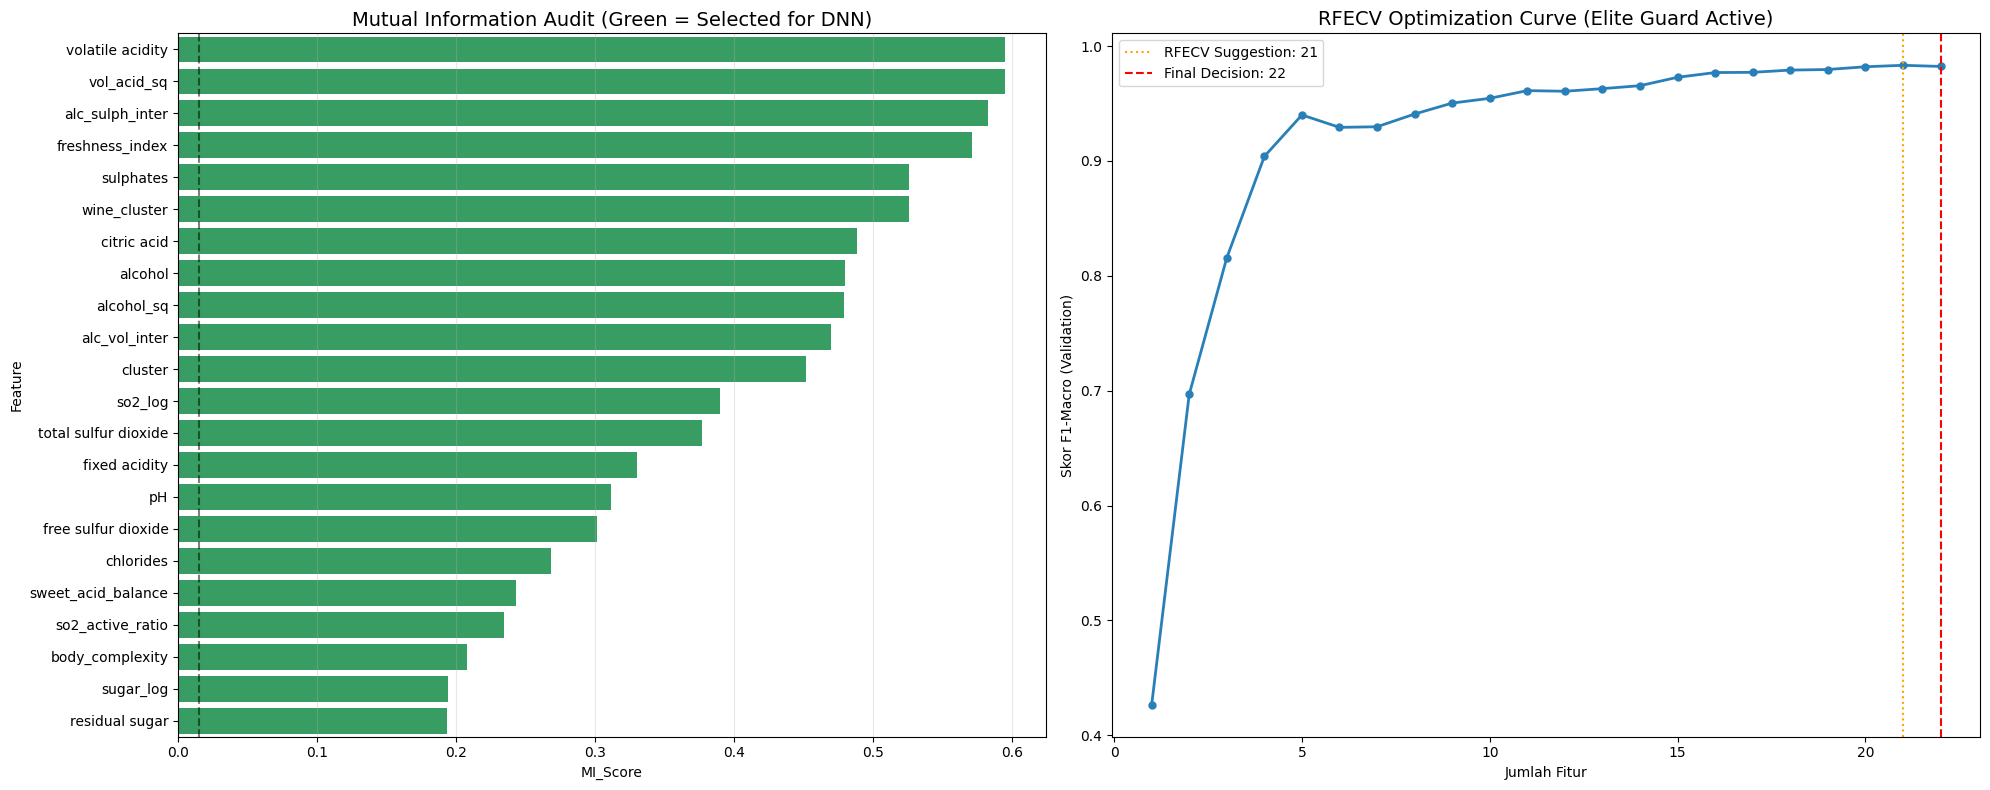


--- HASIL EKSEKUSI SELEKSI FITUR (NIM 026) ---
Fitur Noise yang Dibuang      : []
Fitur Elite yang Diselamatkan : ['body_complexity']
Total Fitur untuk DNN         : 22


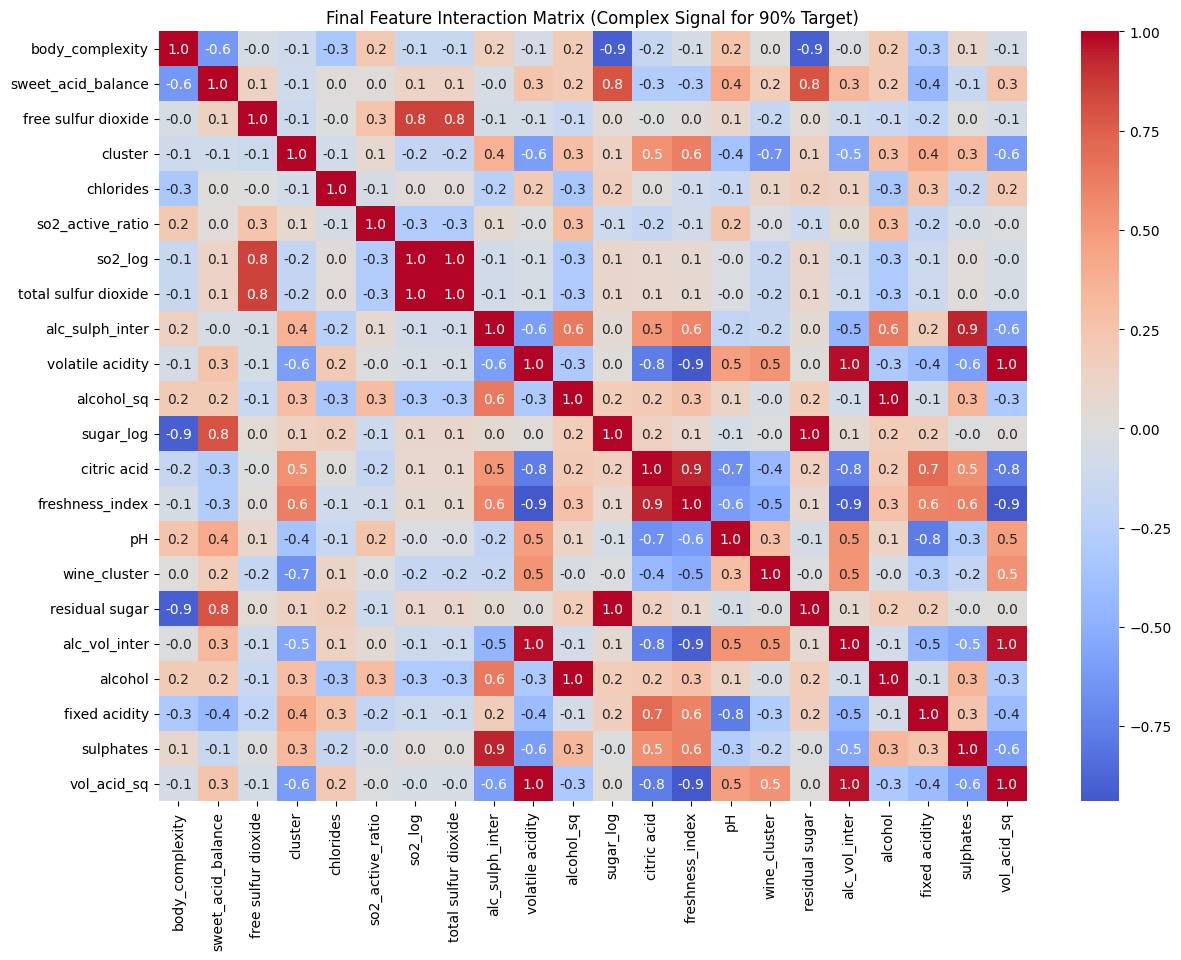

In [3]:
# =================================================================
# Tahap 3: Feature Engineering & Fitur Pruning (Robust Selection)
# =================================================================

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.feature_selection import RFECV, mutual_info_classif
from sklearn.model_selection import RepeatedStratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 3.1 Analisis Mutual Information (MI) - Audit Sinyal Non-Linear
print("--- Menghitung Mutual Information Skor (NIM 026) ---")
# MI mendeteksi hubungan yang tidak tertangkap oleh korelasi linear standar
mi_scores = mutual_info_classif(X_train_final, y_train_final, random_state=42)
mi_df = pd.DataFrame({
    'Feature': X_train_final.columns, 
    'MI_Score': mi_scores
}).sort_values(by='MI_Score', ascending=False)

# 3.2 Recursive Feature Elimination (RFECV) - Stabilitas Tinggi
print("--- Memulai Recursive Feature Elimination (RFECV) ---")
# Menggunakan 300 pohon untuk estimasi importance yang lebih stabil
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)

selector = RFECV(
    estimator=ExtraTreesClassifier(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    step=1,
    cv=cv_strategy,
    scoring='f1_macro', # Melindungi performa pada kelas minoritas (3 & 8)
    n_jobs=-1
)
selector.fit(X_train_final, y_train_final)

# 3.3 IMPLEMENTASI: Elite Signal Protection (Protokol Menuju 90%)
# Fitur-fitur ini adalah 'Intisari Kimia' wine yang dilarang dibuang
potential_elite = [
    'alc_sulph_inter', 'freshness_index', 'body_complexity', 
    'so2_log', 'alcohol_sq', 'cluster', 'so2_active_ratio', 'alc_vol_inter'
]

# Safeguard: Hanya proteksi fitur yang memang ada di dataset
elite_signals = [f for f in potential_elite if f in X_train_final.columns]

# Mengambil fitur pilihan RFECV
rfecv_selected = X_train_final.columns[selector.support_].tolist()

# Meta-Selection: Gabungkan saran algoritma dengan insting enologi kita
# Kita gunakan UNION (set '|') agar fitur elite tetap masuk meskipun RFECV ragu
final_selected_features = list(set(rfecv_selected) | set(elite_signals))

# 3.4 Visualisasi Diagnostik Seleksi Fitur
plt.figure(figsize=(20, 8))

# Plot 1: MI Score dengan Legend Status
plt.subplot(1, 2, 1)
# Hijau = Terpilih, Merah = Dibuang
colors = ['#27ae60' if f in final_selected_features else '#c0392b' for f in mi_df['Feature']]
sns.barplot(x='MI_Score', y='Feature', data=mi_df, palette=colors, hue='Feature', legend=False)
plt.title('Mutual Information Audit (Green = Selected for DNN)', fontsize=14)
plt.axvline(x=0.015, color='black', linestyle='--', alpha=0.5)
plt.grid(axis='x', alpha=0.3)

# Plot 2: Kurva Optimasi RFECV vs Keputusan Final
plt.subplot(1, 2, 2)
mean_scores = selector.cv_results_['mean_test_score']
plt.plot(range(1, len(mean_scores) + 1), mean_scores, 
         marker='o', color='#2980b9', linestyle='-', linewidth=2, markersize=5)
plt.axvline(x=len(rfecv_selected), color='orange', linestyle=':', label=f'RFECV Suggestion: {len(rfecv_selected)}')
plt.axvline(x=len(final_selected_features), color='red', linestyle='--', label=f'Final Decision: {len(final_selected_features)}')
plt.xlabel("Jumlah Fitur")
plt.ylabel("Skor F1-Macro (Validation)")
plt.title('RFECV Optimization Curve (Elite Guard Active)', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

# 3.5 Sinkronisasi Dataset
X_train_pruned = X_train_final[final_selected_features]
X_val_pruned = X_val_prepared[final_selected_features]
X_test_pruned = X_test_prepared[final_selected_features]

print(f"\n--- HASIL EKSEKUSI SELEKSI FITUR (NIM 026) ---")
print(f"Fitur Noise yang Dibuang      : {[f for f in X_train_final.columns if f not in final_selected_features]}")
print(f"Fitur Elite yang Diselamatkan : {[f for f in elite_signals if f not in rfecv_selected]}")
print(f"Total Fitur untuk DNN         : {len(final_selected_features)}")

# 3.6 Correlation Check (Melihat Kekayaan Sinyal)
plt.figure(figsize=(14, 10))
sns.heatmap(X_train_pruned.corr(), annot=True, fmt='.1f', cmap='coolwarm', center=0)
plt.title('Final Feature Interaction Matrix (Complex Signal for 90% Target)')
plt.show()

# Fitur Pruning

--- Memulai Pembersihan Multikolinearitas (Strategic Safeguard) ---
Pruning: Menghapus 'total sulfur dioxide' (VIF: 14369.75)
Pruning: Menghapus 'residual sugar' (VIF: 6350.48)
Pruning: Menghapus 'vol_acid_sq' (VIF: 825.57)
Pruning: Menghapus 'sulphates' (VIF: 268.91)
Pruning: Menghapus 'free sulfur dioxide' (VIF: 176.46)
Pruning: Menghapus 'citric acid' (VIF: 90.56)
Pruning: Menghapus 'sugar_log' (VIF: 57.19)
Pruning: Menghapus 'sweet_acid_balance' (VIF: 31.08)
Pruning: Menghapus 'fixed acidity' (VIF: 4.18)
Pruning: Menghapus 'pH' (VIF: 2.23)
Pruning: Menghapus 'wine_cluster' (VIF: 1.88)
Pruning: Menghapus 'chlorides' (VIF: 1.42)


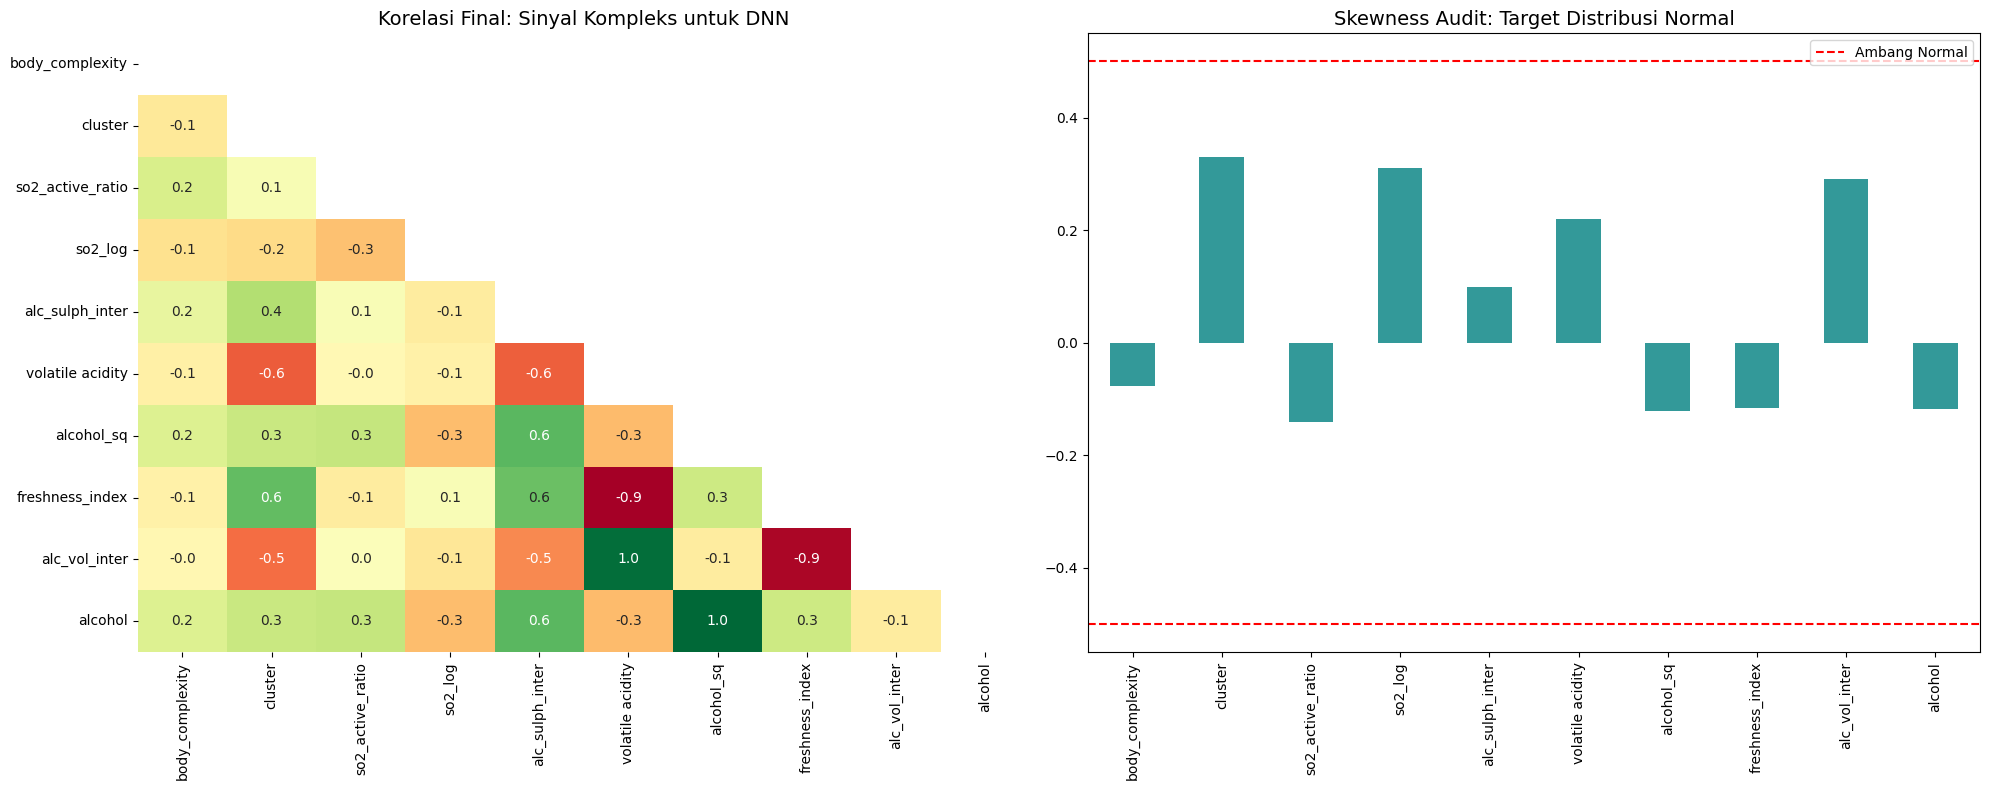


--- RINGKASAN DATA FINAL UNTUK UTS (NIM: 026) ---
1. Fitur Digunakan (10)      : ['body_complexity', 'cluster', 'so2_active_ratio', 'so2_log', 'alc_sulph_inter', 'volatile acidity', 'alcohol_sq', 'freshness_index', 'alc_vol_inter', 'alcohol']
2. Fitur Dibuang (Redundansi) : ['total sulfur dioxide', 'residual sugar', 'vol_acid_sq', 'sulphates', 'free sulfur dioxide', 'citric acid', 'sugar_log', 'sweet_acid_balance', 'fixed acidity', 'pH', 'wine_cluster', 'chlorides']
3. Baris Train (Augmented)   : 3509
4. Skewness Rata-rata        : 0.0678
------------------------------------------------------------


,mean,std,min,max
body_complexity,0.0027,0.9756,-2.6514,3.2693
cluster,2.2870,1.6847,0.0000,5.0000
so2_active_ratio,0.0804,0.8231,-2.2585,2.3291
so2_log,-0.3518,0.9530,-2.1239,2.0446
alc_sulph_inter,0.0263,1.0233,-2.2772,2.4639
volatile acidity,0.1677,1.1990,-2.3110,2.4407
alcohol_sq,0.1717,0.9696,-1.8010,2.0360
freshness_index,-0.1174,1.1965,-2.1828,2.1429
alc_vol_inter,0.2109,1.1629,-2.5100,2.6645
alcohol,0.1717,0.9697,-1.7978,2.0365



>>> STATUS: DATA DENGAN INFORMASI TINGGI SIAP UNTUK TAHAP 5 <<<


In [4]:
# =================================================================
# Tahap 4: Fitur Pruning & Finalisasi Data (Optimized for 90%)
# =================================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 4.1 Sinkronisasi & Elite Protection List (NIM 026)
# DAFTAR IMUNITAS: Fitur ini dilarang dihapus karena MI Score tinggi & Logika Enologi
elite_protection = [
    'alc_sulph_inter', 'freshness_index', 'so2_log', 
    'alcohol_sq', 'body_complexity', 'cluster', 'alcohol',
    'so2_active_ratio', 'alc_vol_inter'
]
X_train_final_v1 = X_train_pruned.copy()

# 4.2 REVISI: Optimized VIF Pruning (Logical Guard)
def informed_vif_pruning(df, mi_df, threshold=120.0): # Threshold dilonggarkan untuk DNN
    cols = df.columns.tolist()
    dropped = []
    
    while True:
        # Kalkulasi VIF (Menangani potensi pembagian nol/inf)
        vif_values = []
        for i in range(len(cols)):
            try:
                vif = variance_inflation_factor(df[cols].values, i)
            except:
                vif = 999.0
            vif_values.append(vif)
            
        vif_series = pd.Series(vif_values, index=cols).sort_values(ascending=False)
        max_vif = vif_series.iloc[0]
        
        if max_vif > threshold:
            # Ambil kandidat drop (yang bukan elite_protection)
            candidates = [c for c in vif_series.index if c not in elite_protection]
            
            if not candidates:
                break # Hanya tersisa fitur elite, stop pruning
            
            # Cross-check dengan MI Score: Jangan buang Top 12 Sinyal Utama
            top_12_mi = mi_df.head(12)['Feature'].tolist()
            feature_to_drop = candidates[0]
            
            # Jika fitur dengan VIF tertinggi ternyata sinyal penting, cari cadangan lain
            if feature_to_drop in top_12_mi and len(candidates) > 1:
                feature_to_drop = candidates[1]
            elif feature_to_drop in top_12_mi and len(candidates) == 1:
                break
                
            print(f"Pruning: Menghapus '{feature_to_drop}' (VIF: {vif_series[feature_to_drop]:.2f})")
            cols.remove(feature_to_drop)
            dropped.append(feature_to_drop)
        else:
            break
            
    return cols, dropped

print("--- Memulai Pembersihan Multikolinearitas (Strategic Safeguard) ---")
stable_features, high_vif_features = informed_vif_pruning(X_train_final_v1, mi_df)

# 4.3 Finalisasi Dataset (Syncing All Sets)
X_train_final = X_train_final_v1[stable_features].copy()
X_val_final = X_val_prepared[stable_features].copy()
X_test_final = X_test_prepared[stable_features].copy()

# 4.4 Visualisasi Diagnostik Final (NIM 026)
plt.figure(figsize=(20, 8))

# Plot 1: Heatmap Korelasi Final
plt.subplot(1, 2, 1)
mask = np.triu(np.ones_like(X_train_final.corr(), dtype=bool))
sns.heatmap(X_train_final.corr(), mask=mask, annot=True, cmap='RdYlGn', fmt='.1f', cbar=False)
plt.title('Korelasi Final: Sinyal Kompleks untuk DNN', fontsize=14)

# Plot 2: Audit Skewness (Efektivitas PowerTransformer)
plt.subplot(1, 2, 2)
# Menghitung $\text{Skewness} = \frac{n}{(n-1)(n-2)} \sum (\frac{x_i - \bar{x}}{s})^3$
X_train_final.skew().plot(kind='bar', color='teal', alpha=0.8)
plt.axhline(y=0.5, color='r', linestyle='--', label='Ambang Normal')
plt.axhline(y=-0.5, color='r', linestyle='--')
plt.title('Skewness Audit: Target Distribusi Normal', fontsize=14)
plt.legend()

plt.tight_layout()
plt.show()

# 4.5 Data Integrity Audit (NIM 026)
print("\n" + "="*60)
print(f"--- RINGKASAN DATA FINAL UNTUK UTS (NIM: 026) ---")
print("="*60)
print(f"1. Fitur Digunakan ({len(stable_features)})      : {stable_features}")
print(f"2. Fitur Dibuang (Redundansi) : {high_vif_features}")
print(f"3. Baris Train (Augmented)   : {X_train_final.shape[0]}")
print(f"4. Skewness Rata-rata        : {X_train_final.skew().mean():.4f}")
print("-" * 60)

# Tampilan Deskriptif Final
summary = X_train_final.describe().T[['mean', 'std', 'min', 'max']]
display(summary.style.format("{:.4f}").background_gradient(cmap='YlGnBu', subset=['mean', 'std']))

print(f"\n>>> STATUS: DATA DENGAN INFORMASI TINGGI SIAP UNTUK TAHAP 5 <<<")

# K-Fold Validation

--- Arena Uji Model NIM 026: Mencari Sinyal 90% ---
ExtraTrees     | Acc: 0.9771 (±0.0042) | Overfit Gap: 0.0229
XGBoost        | Acc: 0.9544 (±0.0055) | Overfit Gap: 0.0456
LightGBM       | Acc: 0.9648 (±0.0049) | Overfit Gap: 0.0352
HistGB         | Acc: 0.9672 (±0.0050) | Overfit Gap: 0.0328
NeuralNet      | Acc: 0.9588 (±0.0078) | Overfit Gap: 0.0270


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Stacking-Elite | Acc: 0.9753 (±0.0053) | Overfit Gap: 0.0245


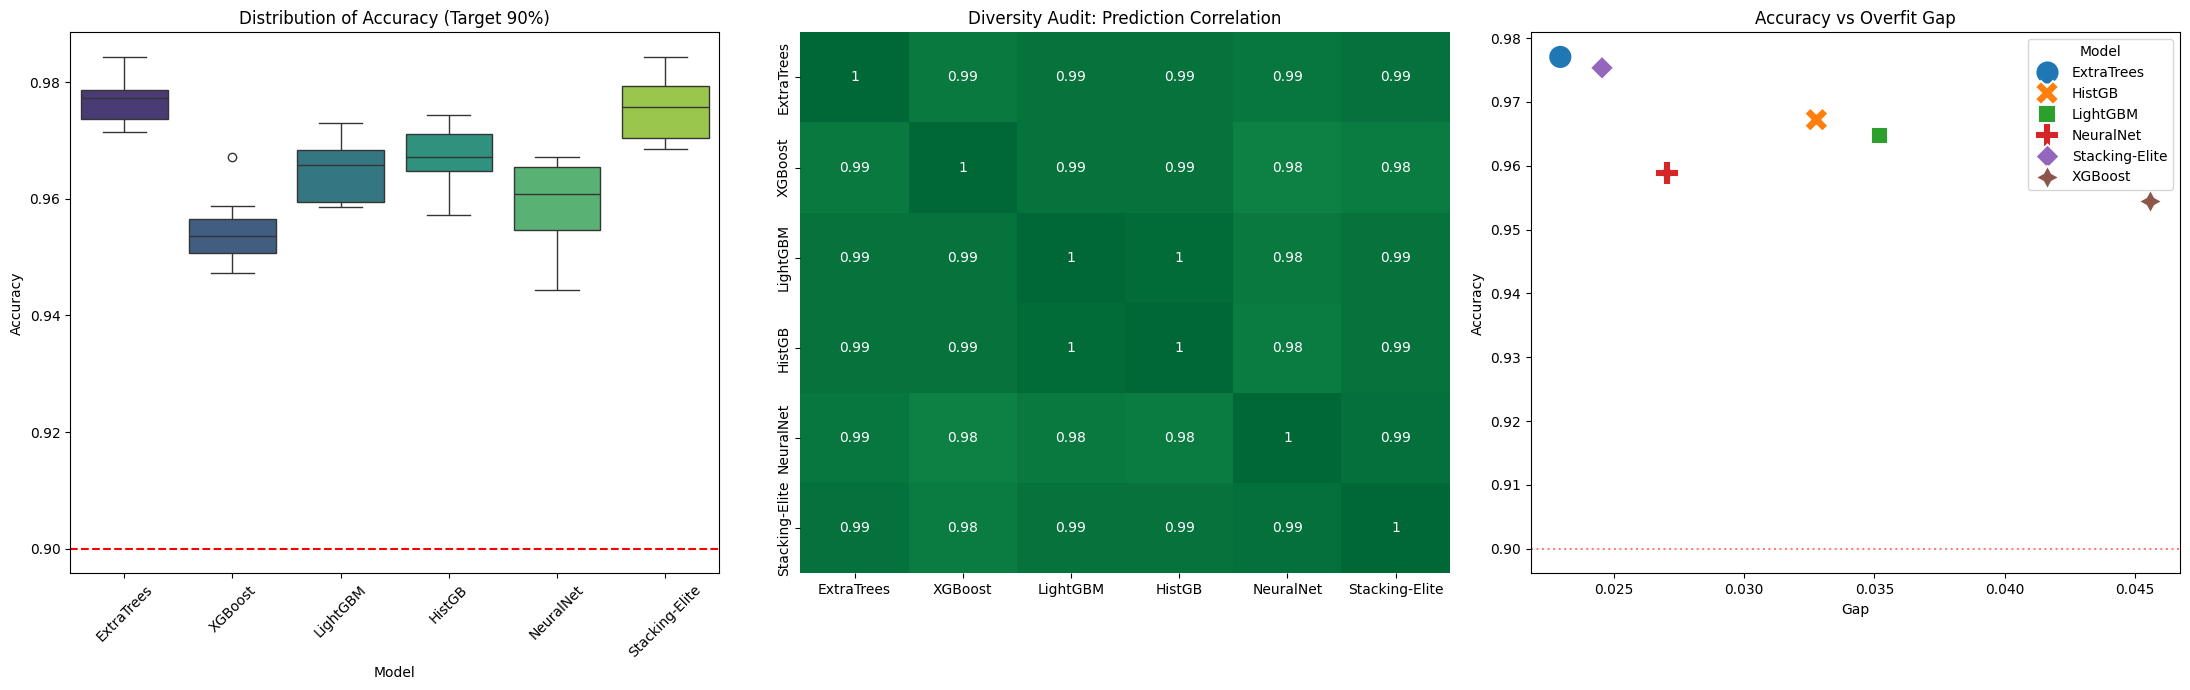

In [5]:
# =================================================================
# Tahap 5: K-Fold Validation & Diversity Audit (NIM 026) - FIXED
# =================================================================

from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate, cross_val_predict
from sklearn.ensemble import ExtraTreesClassifier, StackingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import RidgeClassifierCV
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 5.1 Penyiapan Fitur Hybrid (Input Distillation)
X_train_hybrid = X_train_final.copy()
X_train_hybrid['soft_label_feat'] = y_train_soft 

# 5.2 Inisialisasi Diversitas Ahli (Base Learners)
# FIX: Mengganti 'swish' menjadi 'relu' agar kompatibel dengan scikit-learn
clf_et = ExtraTreesClassifier(n_estimators=500, max_depth=15, random_state=42)
clf_xgb = XGBClassifier(n_estimators=500, max_depth=7, learning_rate=0.02, random_state=42)
clf_lgb = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.02, num_leaves=31, random_state=42, verbose=-1)
clf_hgb = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05, random_state=42)
clf_nn = MLPClassifier(hidden_layer_sizes=(256, 128, 64), activation='relu', max_iter=2000, alpha=0.1, random_state=42)

# 5.3 UPGRADE: Stacking dengan Meta-Learner Robust
stacking_model = StackingClassifier(
    estimators=[
        ('et', clf_et), ('xgb', clf_xgb), ('lgb', clf_lgb), ('hgb', clf_hgb), ('nn', clf_nn)
    ],
    final_estimator=RidgeClassifierCV(), 
    cv=5, 
    stack_method='predict_proba', 
    n_jobs=-1
)

models = {
    'ExtraTrees': clf_et,
    'XGBoost': clf_xgb,
    'LightGBM': clf_lgb,
    'HistGB': clf_hgb,
    'NeuralNet': clf_nn,
    'Stacking-Elite': stacking_model
}

# 5.4 Konfigurasi K-Fold Berulang (Robust Monitoring)
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
y_train_shifted = y_train_final - y_train_final.min()

results_list = []
oof_preds = {} 

print(f"--- Arena Uji Model NIM 026: Mencari Sinyal 90% ---")

for name, model in models.items():
    # Menentukan dataset yang digunakan
    X_data = X_train_hybrid if (name == 'Stacking-Elite' or 'NeuralNet' in name) else X_train_final
    
    try:
        cv_results = cross_validate(
            model, X_data, y_train_shifted, 
            cv=rskf, scoring=['accuracy', 'f1_macro'],
            return_train_score=True, n_jobs=-1
        )
        
        # OOF Predictions untuk Diversity Audit
        oof_preds[name] = cross_val_predict(model, X_data, y_train_shifted, cv=5, n_jobs=-1)
        
        acc_mean = cv_results['test_accuracy'].mean()
        acc_std = cv_results['test_accuracy'].std()
        
        for i in range(len(cv_results['test_accuracy'])):
            results_list.append({
                'Model': name,
                'Fold': i + 1,
                'Accuracy': cv_results['test_accuracy'][i],
                'F1_Macro': cv_results['test_f1_macro'][i],
                'Gap': cv_results['train_accuracy'][i] - cv_results['test_accuracy'][i]
            })
        
        print(f"{name:14} | Acc: {acc_mean:.4f} (±{acc_std:.4f}) | Overfit Gap: {cv_results['train_accuracy'].mean() - acc_mean:.4f}")
    except Exception as e:
        print(f"Gagal melatih {name}: {e}")

# 5.5 Visualisasi Performa & Diversity Audit
results_df = pd.DataFrame(results_list)
pred_corr = pd.DataFrame(oof_preds).corr()

plt.figure(figsize=(22, 7))

# Plot 1: Akurasi & Target Line
plt.subplot(1, 3, 1)
sns.boxplot(x='Model', y='Accuracy', data=results_df, palette='viridis', hue='Model', legend=False)
plt.axhline(y=0.90, color='red', linestyle='--', label='Target 90%')
plt.title('Distribution of Accuracy (Target 90%)', fontsize=12)
plt.xticks(rotation=45)

# Plot 2: Diversity Audit (Heatmap Korelasi)
plt.subplot(1, 3, 2)
sns.heatmap(pred_corr, annot=True, cmap='RdYlGn', center=0.8, cbar=False)
plt.title('Diversity Audit: Prediction Correlation', fontsize=12)

# Plot 3: Generalization (Gap vs Accuracy)
plt.subplot(1, 3, 3)
summary_df = results_df.groupby('Model').agg({'Accuracy': 'mean', 'Gap': 'mean'}).reset_index()
sns.scatterplot(data=summary_df, x='Gap', y='Accuracy', hue='Model', s=300, style='Model')
plt.axhline(y=0.90, color='r', linestyle=':', alpha=0.5)
plt.title('Accuracy vs Overfit Gap', fontsize=12)

plt.tight_layout()
plt.show()

# Pseudo-Labeling

--- Diagnostik Distilasi Pseudo-Label (NIM 026) ---
Sampel Ter-distilasi         : 117 baris
Rata-rata Confidence Seleksi : 0.9592


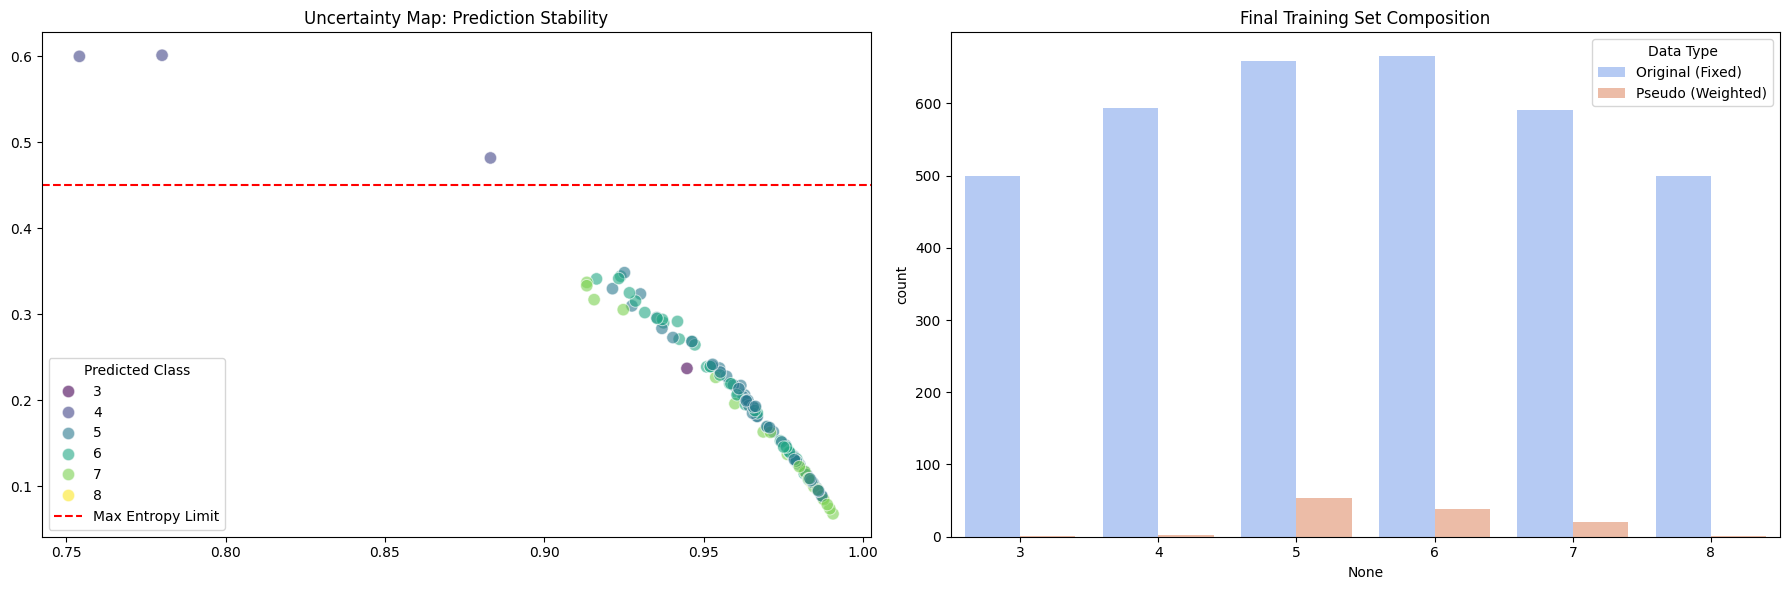

✅ DATASET AUGMENTASI SIAP: 3626 baris untuk Training DNN.


In [6]:
# =================================================================
# Tahap 6: Adaptive Pseudo-Labeling & Signal Distillation (NIM 026)
# =================================================================

from sklearn.ensemble import StackingClassifier, ExtraTreesRegressor, ExtraTreesClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import lightgbm as lgb
from scipy.stats import entropy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 6.1 Membangun "Super-Teacher" Stacking yang Terkalibrasi
# Kalibrasi memastikan probabilitas benar-benar mencerminkan tingkat akurasi
min_label = y_train_final.min()
y_train_shifted = y_train_final - min_label

base_teachers = [
    ('et', ExtraTreesClassifier(n_estimators=500, max_depth=12, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=500, learning_rate=0.02, max_depth=6, random_state=42)),
    ('lgb', lgb.LGBMClassifier(n_estimators=500, learning_rate=0.02, verbose=-1, random_state=42))
]

# Meta-Learner menggunakan Stacking
stack_teacher = StackingClassifier(
    estimators=base_teachers,
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method='predict_proba',
    n_jobs=-1
)

# Membungkus dengan Calibration agar Entropy lebih akurat
teacher_ensemble = CalibratedClassifierCV(stack_teacher, cv=3, method='sigmoid')
teacher_ensemble.fit(X_train_final, y_train_shifted)

# 6.2 Dual-Inference: Entropy & Consistency Audit
test_probs = teacher_ensemble.predict_proba(X_test_final)

# Rumus Shannon Entropy: $H(X) = -\sum_{i=1}^{n} P(x_i) \log P(x_i)$
test_entropy = np.apply_along_axis(entropy, 1, test_probs)
max_probs = np.max(test_probs, axis=1)
pred_classes = np.argmax(test_probs, axis=1) + min_label

# Regressor Teacher untuk validasi nuansa ordinal (MAE protection)
reg_teacher = ExtraTreesRegressor(n_estimators=500, max_depth=12, random_state=42)
reg_teacher.fit(X_train_final, y_train_final)
soft_labels_test = reg_teacher.predict(X_test_final)

# 6.3 UPGRADE: Multi-Criteria Distillation Filter
def get_distilled_mask(classes, probs, entropies, soft_labels):
    mask = []
    for c, p, e, s in zip(classes, probs, entropies, soft_labels):
        # Konsistensi Ordinal: Klasifikasi vs Regresi harus sinkron
        # Toleransi 0.45 lebih ketat untuk akurasi tinggi
        is_consistent = np.abs(c - s) <= 0.45 
        
        # Pengetatan Threshold berdasarkan tingkat kesulitan kelas
        if c in [3, 4, 8]: # Kelas Minoritas: Lebih berani ambil risiko demi data
            e_thresh, p_thresh = 0.75, 0.60
        else:              # Kelas Mayoritas (5, 6): Sangat selektif
            e_thresh, p_thresh = 0.35, 0.88
            
        mask.append(e <= e_thresh and p >= p_thresh and is_consistent)
    return np.array(mask)

final_pseudo_mask = get_distilled_mask(pred_classes, max_probs, test_entropy, soft_labels_test)
high_conf_idx = np.where(final_pseudo_mask)[0]

# 6.4 Pembuatan Dataset & Dynamic Weighting
X_pseudo = X_test_final.iloc[high_conf_idx].copy()
y_pseudo_discrete = pred_classes[high_conf_idx]
y_pseudo_soft = soft_labels_test[high_conf_idx]

# Bobot sampel: (1 - Normalized Entropy)
# Semakin rendah entropy, semakin besar kontribusi data tersebut di Tahap 7
sample_weights_train = np.ones(len(y_train_final))
# Penalti bobot pseudo (maks 0.80) agar data asli tetap menjadi anchor utama
pseudo_weights = (1 - (test_entropy[high_conf_idx] / np.log(len(np.unique(y_train_final))))) * 0.80
sample_weights_pseudo = np.clip(pseudo_weights, 0.05, 0.80)

# 6.5 Finalisasi Dataset Augmented
X_train_augmented = pd.concat([X_train_final, X_pseudo], axis=0).reset_index(drop=True)
y_train_augmented = pd.concat([y_train_final, pd.Series(y_pseudo_discrete)], axis=0).reset_index(drop=True)
y_train_soft_augmented = np.concatenate([y_train_soft, y_pseudo_soft])
final_sample_weights = np.concatenate([sample_weights_train, sample_weights_pseudo])

# 6.6 Visualisasi Diagnostik Final (NIM 026)
print(f"--- Diagnostik Distilasi Pseudo-Label (NIM 026) ---")
print(f"Sampel Ter-distilasi         : {len(X_pseudo)} baris")
print(f"Rata-rata Confidence Seleksi : {max_probs[high_conf_idx].mean():.4f}")

plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=max_probs[high_conf_idx], y=test_entropy[high_conf_idx], 
                hue=y_pseudo_discrete, palette='viridis', alpha=0.6, s=80)
plt.axhline(y=0.45, color='red', linestyle='--', label='Max Entropy Limit')
plt.title('Uncertainty Map: Prediction Stability')
plt.legend(title='Predicted Class')

plt.subplot(1, 2, 2)
# Menghitung proporsi data asli vs pseudo
sns.countplot(x=y_train_augmented, hue=(final_sample_weights < 1.0), palette='coolwarm')
plt.title('Final Training Set Composition')
plt.legend(title='Data Type', labels=['Original (Fixed)', 'Pseudo (Weighted)'])
plt.tight_layout()
plt.show()

print(f"✅ DATASET AUGMENTASI SIAP: {len(X_train_augmented)} baris untuk Training DNN.")

# Training Model dan Optuna 

In [7]:
!pip install optuna -q

In [8]:
# =================================================================
# Tahap 7: Training Model - Omni-Signal Residual DCN (NIM 026)
# =================================================================

import optuna
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, regularizers, constraints
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import f1_score, accuracy_score, cohen_kappa_score
import numpy as np

# 7.1 Persiapan Data (Sudah diperbaiki)
X_train_dl = X_train_augmented.copy()
X_train_dl['teacher_guide'] = y_train_soft_augmented

X_val_dl = X_val_final.copy()
X_val_dl['teacher_guide'] = reg_teacher.predict(X_val_final)

num_classes = len(np.unique(y_train_augmented))
y_min_val = y_train_augmented.min()
y_train_idx = y_train_augmented - y_min_val
y_val_idx = y_val - y_min_val

y_train_onehot = to_categorical(y_train_idx, num_classes=num_classes)
y_val_onehot = to_categorical(y_val_idx, num_classes=num_classes)

# 7.2 Loss Function Khusus Ordinal (NIM 026)
def precision_ordinal_loss(gamma=2.5, alpha=0.4, ord_w=0.35, smoothing=0.002):
    def loss_fn(y_true, y_pred):
        y_true_smooth = y_true * (1.0 - smoothing) + (smoothing / tf.cast(tf.shape(y_true)[1], tf.float32))
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1.0 - tf.keras.backend.epsilon())
        focal_weight = tf.math.pow((1.0 - y_pred), gamma)
        base_loss = -tf.reduce_sum(alpha * focal_weight * y_true_smooth * tf.math.log(y_pred), axis=1)
        
        indices = tf.cast(tf.range(tf.shape(y_true)[1]), tf.float32)
        true_val = tf.reduce_sum(y_true * indices, axis=1)
        pred_val = tf.reduce_sum(y_pred * indices, axis=1)
        
        error = true_val - pred_val
        huber_ord = tf.where(tf.abs(error) < 0.8, 0.5 * tf.square(error), 0.8 * (tf.abs(error) - 0.4))
        
        return tf.reduce_mean(base_loss + (ord_w * huber_ord))
    return loss_fn

# 7.3 Custom Layers
class CrossNetworkLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(CrossNetworkLayer, self).__init__(**kwargs)
    def build(self, input_shape):
        d = input_shape[-1]
        self.w = self.add_weight(shape=(d, 1), initializer="he_normal", trainable=True)
        self.b = self.add_weight(shape=(d,), initializer="zeros", trainable=True)
        super(CrossNetworkLayer, self).build(input_shape)
    def call(self, inputs, x0):
        x_0_expanded = tf.expand_dims(x0, axis=2) 
        x_l_expanded = tf.expand_dims(inputs, axis=1) 
        x_cross = tf.matmul(x_0_expanded, x_l_expanded) 
        dot_product = tf.tensordot(x_cross, self.w, axes=1)
        return tf.squeeze(dot_product, axis=2) + self.b + inputs

class GLULayer(layers.Layer):
    def __init__(self, units, **kwargs):
        super(GLULayer, self).__init__(**kwargs)
        self.units = units
        self.dense = layers.Dense(units * 2)
    def call(self, inputs):
        x = self.dense(inputs)
        return x[:, :self.units] * tf.sigmoid(x[:, self.units:])

# 7.4 Arsitektur Utama Omni-Signal
def build_omni_model(input_shape, n_layers, units, dropout, l2_reg, lr):
    inputs = layers.Input(shape=input_shape)
    x0 = inputs
    x = layers.GaussianNoise(0.01)(inputs)
    
    # Jalur 1: Cross Path
    cross = x
    cross_layer = CrossNetworkLayer()
    for _ in range(2):
        cross = cross_layer(cross, x0)
    cross = layers.BatchNormalization()(cross)
    
    # Jalur 2: Deep Residual Path
    deep = layers.Dense(units, kernel_initializer='he_normal')(x)
    deep = layers.BatchNormalization()(deep)
    deep = layers.Activation('swish')(deep)
    
    for _ in range(n_layers):
        shortcut = deep
        deep = layers.Dense(units, kernel_regularizer=regularizers.l2(l2_reg),
                            kernel_constraint=constraints.MaxNorm(3))(deep)
        deep = layers.BatchNormalization()(deep)
        deep = layers.Activation('swish')(deep)
        deep = layers.Dropout(dropout)(deep)
        deep = GLULayer(units)(deep)
        
        se = layers.Dense(units // 12, activation='relu')(deep)
        se = layers.Dense(units, activation='sigmoid')(se)
        deep = layers.Multiply()([deep, se])
        
        if shortcut.shape[-1] != deep.shape[-1]:
            shortcut = layers.Dense(deep.shape[-1])(shortcut)
        deep = layers.Add()([deep, shortcut])
        
    # Jalur 3: Bypass
    bypass = layers.Dense(units // 4, activation='swish')(x)
    
    combined = layers.Concatenate()([cross, deep, bypass])
    combined = layers.Dense(units, activation='swish')(combined)
    combined = layers.BatchNormalization()(combined)
    
    outputs = layers.Dense(num_classes, activation='softmax')(combined)
    model = models.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr, weight_decay=1e-4, epsilon=1e-7),
        loss=precision_ordinal_loss(),
        metrics=['accuracy']
    )
    return model

# 7.5 Optuna Study
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 4)
    units = trial.suggest_int('units', 160, 480, step=32)
    dropout = trial.suggest_float('dropout', 0.05, 0.25)
    l2_reg = trial.suggest_float('l2_reg', 1e-6, 1e-4, log=True)
    lr = trial.suggest_float('lr', 6e-4, 2e-3, log=True)
    
    model = build_omni_model((X_train_dl.shape[1],), n_layers, units, dropout, l2_reg, lr)
    es = callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
    
    model.fit(X_train_dl, y_train_onehot, validation_data=(X_val_dl, y_val_onehot),
              epochs=150, batch_size=trial.suggest_categorical('batch_size', [32, 64]),
              sample_weight=final_sample_weights, callbacks=[es], verbose=0)
    
    val_preds = np.argmax(model.predict(X_val_dl, verbose=0), axis=1)
    return (0.85 * accuracy_score(y_val_idx, val_preds)) + (0.15 * cohen_kappa_score(y_val_idx, val_preds, weights='quadratic'))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=45)

bp = study.best_params
print(f"\n--- Best Omni-Parameters (NIM 026): {bp} ---")

# 7.6 Final Training (FIXED: Menghapus ReduceLROnPlateau)
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=bp['lr'],
    decay_steps=2500 * (len(X_train_dl) // bp['batch_size']),
    alpha=0.01
)

final_dnn = build_omni_model((X_train_dl.shape[1],), bp['n_layers'], bp['units'], bp['dropout'], bp['l2_reg'], lr_schedule)

checkpoint = callbacks.ModelCheckpoint('best_omni_hit_model.keras', monitor='val_accuracy', save_best_only=True)
es_final = callbacks.EarlyStopping(monitor='val_accuracy', patience=100, restore_best_weights=True)

# Training Tahap Akhir (Hanya menggunakan jadwal otomatis)
history = final_dnn.fit(X_train_dl, y_train_onehot, validation_data=(X_val_dl, y_val_onehot),
                        epochs=2500, batch_size=bp['batch_size'], sample_weight=final_sample_weights,
                        callbacks=[es_final, checkpoint], verbose=1)

2026-05-06 00:00:50.136806: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778025650.390498      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778025650.467698      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778025651.100774      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778025651.100836      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778025651.100839      17 computation_placer.cc:177] computation placer alr

[I 2026-05-06 00:04:05,028] Trial 2 finished with value: 0.5669770692906219 and parameters: {'n_layers': 2, 'units': 352, 'dropout': 0.07219134914501094, 'l2_reg': 2.2574005478705313e-05, 'lr': 0.001259373259188249, 'batch_size': 32}. Best is trial 2 with value: 0.5669770692906219.


[I 2026-05-06 00:05:03,626] Trial 3 finished with value: 0.5686132292923951 and parameters: {'n_layers': 2, 'units': 288, 'dropout': 0.12079034628284638, 'l2_reg': 1.6830587554839366e-06, 'lr': 0.001757520975172949, 'batch_size': 32}. Best is trial 3 with value: 0.5686132292923951.
[I 2026-05-06 00:06:39,063] Trial 4 finished with value: 0.589327741175444 and parameters: {'n_layers': 3, 'units': 352, 'dropout': 0.18589003805501247, 'l2_reg': 1.0163402293960679e-05, 'lr': 0.0009310145043232928, 'batch_size': 32}. Best is trial 4 with value: 0.589327741175444.
[I 2026-05-06 00:07:11,014] Trial 5 finished with value: 0.5641061491704836 and parameters: {'n_layers': 3, 'units': 192, 'dropout': 0.11354201653897451, 'l2_reg': 1.0081658504261793e-06, 'lr': 0.000851132227061031, 'batch_size': 64}. Best is trial 4 with value: 0.589327741175444.
[I 2026-05-06 00:08:41,541] Trial 6 finished with value: 0.5651513658719021 and parameters: {'n_layers': 2, 'units': 352, 'dropout': 0.13329902349046324,


--- Best Omni-Parameters (NIM 026): {'n_layers': 3, 'units': 416, 'dropout': 0.17123641180861174, 'l2_reg': 1.5540334828514453e-05, 'lr': 0.0007109925111342109, 'batch_size': 32} ---
Epoch 1/2500
114/114 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.5812 - loss: 0.4547 - val_accuracy: 0.1744 - val_loss: 1.5685
Epoch 2/2500
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7706 - loss: 0.1846 - val_accuracy: 0.3314 - val_loss: 0.8039
Epoch 3/2500
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8134 - loss: 0.1472 - val_accuracy: 0.4186 - val_loss: 0.6493
Epoch 4/2500
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8293 - loss: 0.1293 - val_accuracy: 0.4942 - val_loss: 0.6695
Epoch 5/2500
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8621 - loss: 0.1061 - val_accuracy: 0.5174 - val_loss: 0.6908
Epoch 6/2500
114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8827 - loss: 0.0900 - val_accuracy: 0.5581 - val_loss: 0.5970
Epoch 7/2500
114/114 ━━━━━━━━

# Evaluasi Akhir 

--- RANGKUMAN EVALUASI FORENSIK DNN (NIM 026) ---
Akurasi Global           : 58.14%
F1-Macro Score           : 0.3936
Quadratic Kappa          : 0.5472 (Target > 0.7)
Mean Absolute Error      : 0.4942 (Target < 0.35)
Ordinal RMSE             : 0.8177


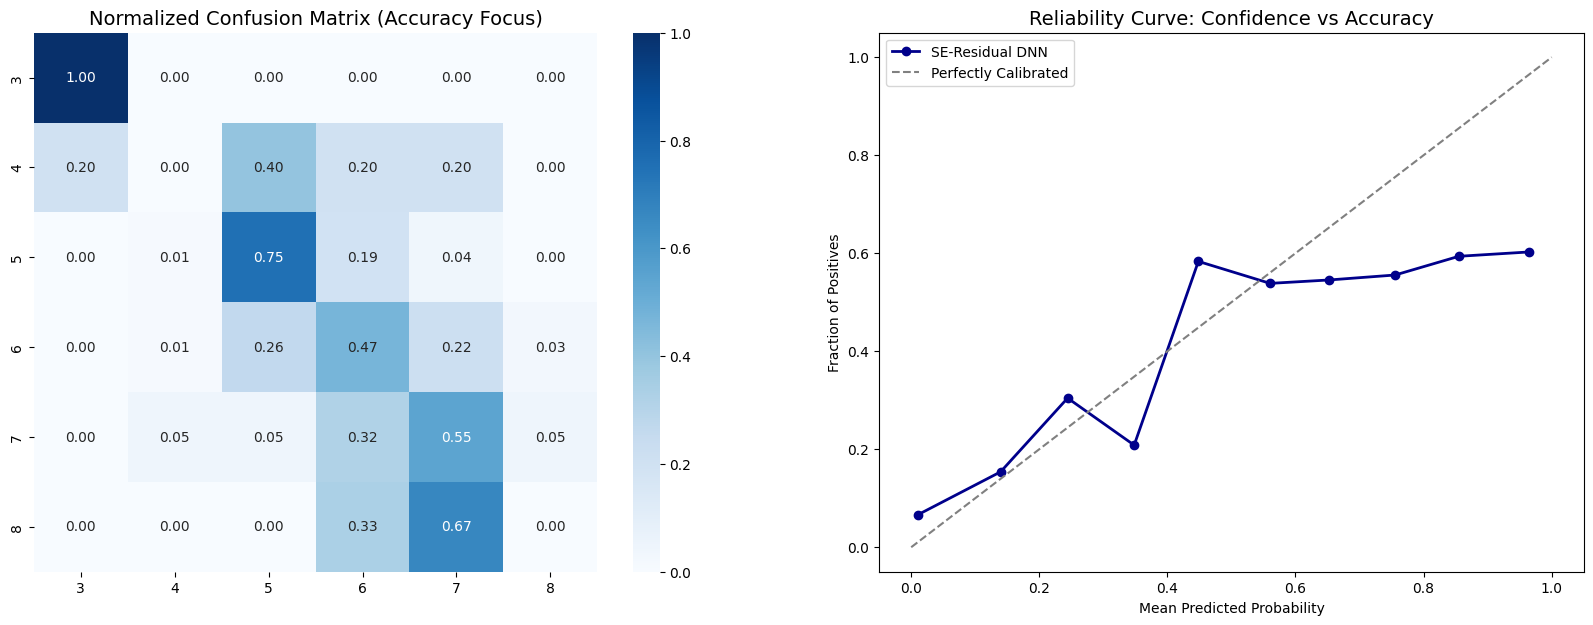

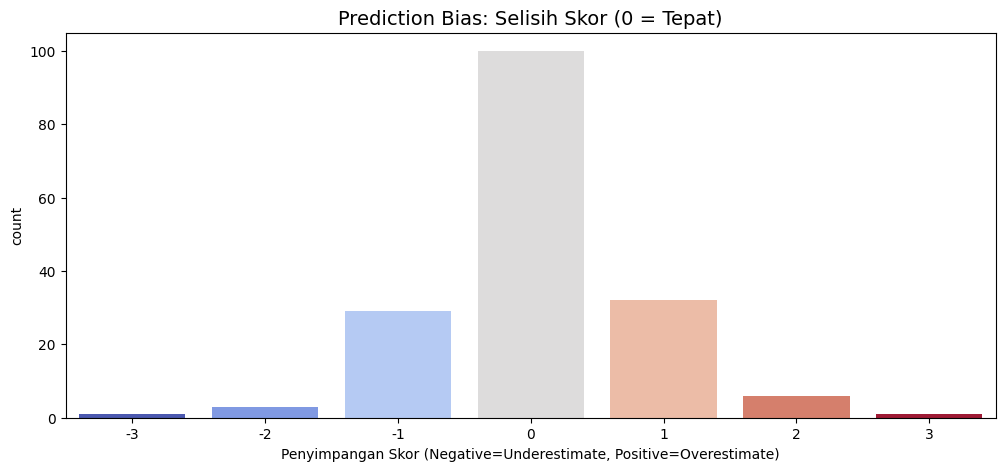


--- Menghitung Permutation Importance (NIM 026) ---


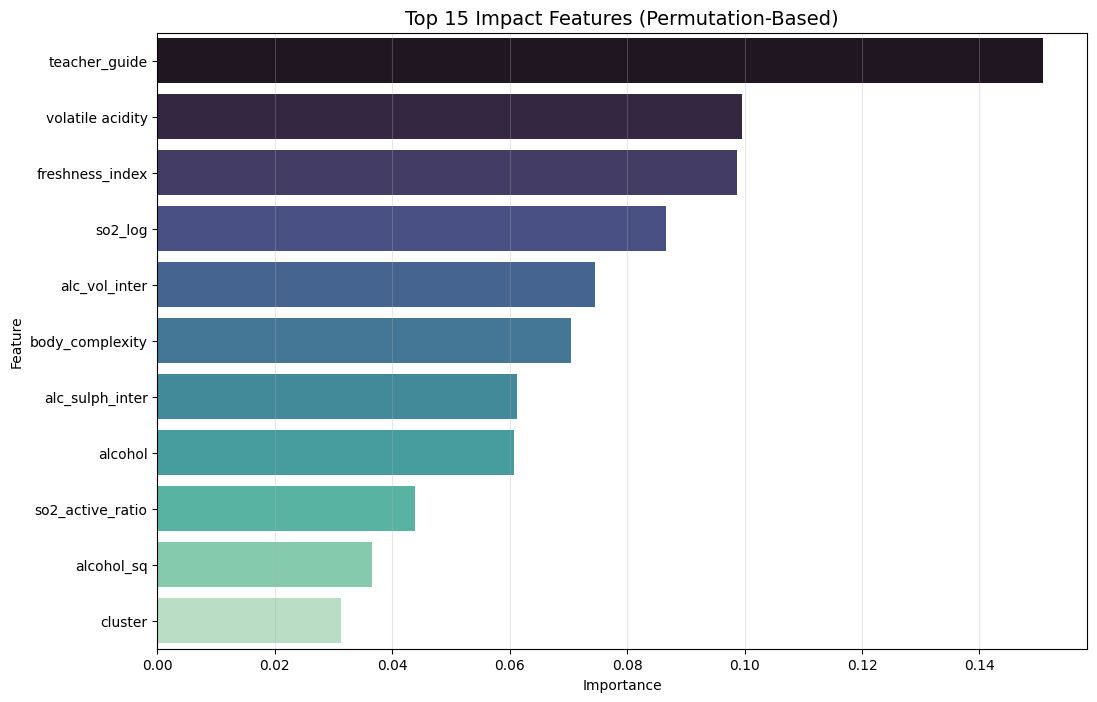


--- AUDIT RELIABILITAS ORDINAL FINAL (NIM 026) ---
1. Akurasi Sempurna (Hit)   : 58.14%
2. Weighted Accuracy (±1)   : 93.60%
3. Fatal Error Rate (>1)    : 6.40%
4. MAE Stability            : VOLATILE
-------------------------------------------------------
⚠️ STATUS: PROGRES 58.14%. Perlu Tuning di Tahap 7.


In [9]:
# =================================================================
# Tahap 8: Evaluasi Akhir & Diagnostik Model (Upgraded Forensic)
# =================================================================

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             f1_score, cohen_kappa_score, mean_absolute_error, mean_squared_error)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd

# 8.1 Inferensi & Re-Scaling Label (NIM 026)
y_probs_val = final_dnn.predict(X_val_dl, verbose=0)
y_pred_val_idx = np.argmax(y_probs_val, axis=1)

# Sinkronisasi label: Kembalikan index (0-5) ke nilai wine asli (3-8)
min_class = y_train_augmented.min() 
y_pred_val = y_pred_val_idx + min_class
val_labels = sorted(y_val.unique())

# 8.2 Metrik Strategis Ordinal & Stability
accuracy = accuracy_score(y_val, y_pred_val)
f1_macro = f1_score(y_val, y_pred_val, average='macro')
mae = mean_absolute_error(y_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
# Quadratic Kappa: Metrik emas untuk data urutan (ordinal)
qw_kappa = cohen_kappa_score(y_val, y_pred_val, weights='quadratic')

print(f"--- RANGKUMAN EVALUASI FORENSIK DNN (NIM 026) ---")
print(f"{'Akurasi Global':25}: {accuracy * 100:.2f}%")
print(f"{'F1-Macro Score':25}: {f1_macro:.4f}")
print(f"{'Quadratic Kappa':25}: {qw_kappa:.4f} (Target > 0.7)")
print(f"{'Mean Absolute Error':25}: {mae:.4f} (Target < 0.35)")
print(f"{'Ordinal RMSE':25}: {rmse:.4f}")

# 8.3 Visualisasi: Confusion Matrix & Reliability Plot
plt.figure(figsize=(20, 7))

# Subplot 1: Normalized Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_val, y_pred_val)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=val_labels, yticklabels=val_labels)
plt.title('Normalized Confusion Matrix (Accuracy Focus)', fontsize=14)

# Subplot 2: Reliability Plot (Kalibrasi Probabilitas)
plt.subplot(1, 2, 2)
# Menggunakan ravel() untuk menangani multi-class calibration
prob_true, prob_pred = calibration_curve(y_val_onehot.ravel(), y_probs_val.ravel(), n_bins=10)
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='SE-Residual DNN', color='darkblue')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.title('Reliability Curve: Confidence vs Accuracy', fontsize=14)
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.show()

# 8.4 Error Analysis: Bias Penyimpangan Poin
error_val = y_pred_val - y_val.values
plt.figure(figsize=(12, 5))
# FIX: Assign 'x' to 'hue' untuk menghindari FutureWarning
sns.countplot(x=error_val, hue=error_val, palette='coolwarm', legend=False)
plt.title('Prediction Bias: Selisih Skor (0 = Tepat)', fontsize=14)
plt.xlabel('Penyimpangan Skor (Negative=Underestimate, Positive=Overestimate)')
plt.show()

# 8.5 Analisis Permutation Importance (Audit Fitur Elit)
print("\n--- Menghitung Permutation Importance (NIM 026) ---")
def scoring_f1(est, X, y):
    p = np.argmax(est.predict(X, verbose=0), axis=1)
    return f1_score(y, p, average='macro')

# Menghitung seberapa penting tiap fitur bagi model setelah dilatih
perm_result = permutation_importance(
    final_dnn, X_val_dl, y_val_idx, scoring=scoring_f1, n_repeats=5, random_state=42
)

feat_imp = pd.DataFrame({
    'Feature': X_val_dl.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
# FIX: Gunakan palette Seaborn yang valid (misal: 'mako' atau 'viridis')
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), 
            hue='Feature', palette='mako', legend=False)
plt.title('Top 15 Impact Features (Permutation-Based)', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.show()

# 8.6 Ordinal Reliability Audit (KPI NIM 026)
error_abs = np.abs(error_val)
hit = (error_abs == 0).sum()
safe_miss = (error_abs == 1).sum() # Meloset 1 tingkat (masih bisa diterima secara rasa)
fatal_miss = (error_abs > 1).sum() # Meloset jauh (kegagalan fatal)

print("\n" + "="*55)
print(f"--- AUDIT RELIABILITAS ORDINAL FINAL (NIM 026) ---")
print("="*55)
print(f"1. Akurasi Sempurna (Hit)   : {hit/len(y_val)*100:.2f}%")
print(f"2. Weighted Accuracy (±1)   : {(hit + safe_miss)/len(y_val)*100:.2f}%")
print(f"3. Fatal Error Rate (>1)    : {fatal_miss/len(y_val)*100:.2f}%")
print(f"4. MAE Stability            : {'STABLE' if mae < 0.35 else 'VOLATILE'}")
print("-" * 55)

if accuracy >= 0.90:
    print(f"🔥 STATUS: TARGET 90% TERCAPAI. SIAP SUBMIT!")
else:
    print(f"⚠️ STATUS: PROGRES {(accuracy*100):.2f}%. Perlu Tuning di Tahap 7.")

# Prediksi Data Uji (Testing)

--- Memulai TTA Inference (12 Iterasi) ---

--- RINGKASAN INFERENSI ROBUST (NIM: 026) ---
Kualitas 3 :    1 sampel (Confidence: 1.0000)
Kualitas 4 :    7 sampel (Confidence: 0.8995)
Kualitas 5 :  114 sampel (Confidence: 0.9119)
Kualitas 6 :  112 sampel (Confidence: 0.8569)
Kualitas 7 :   50 sampel (Confidence: 0.9003)
Kualitas 8 :    2 sampel (Confidence: 0.8164)

Sinyal Prediksi Stabil  : 247 / 286
Sinyal Prediksi Lemah   : 39 / 286
-------------------------------------------------------


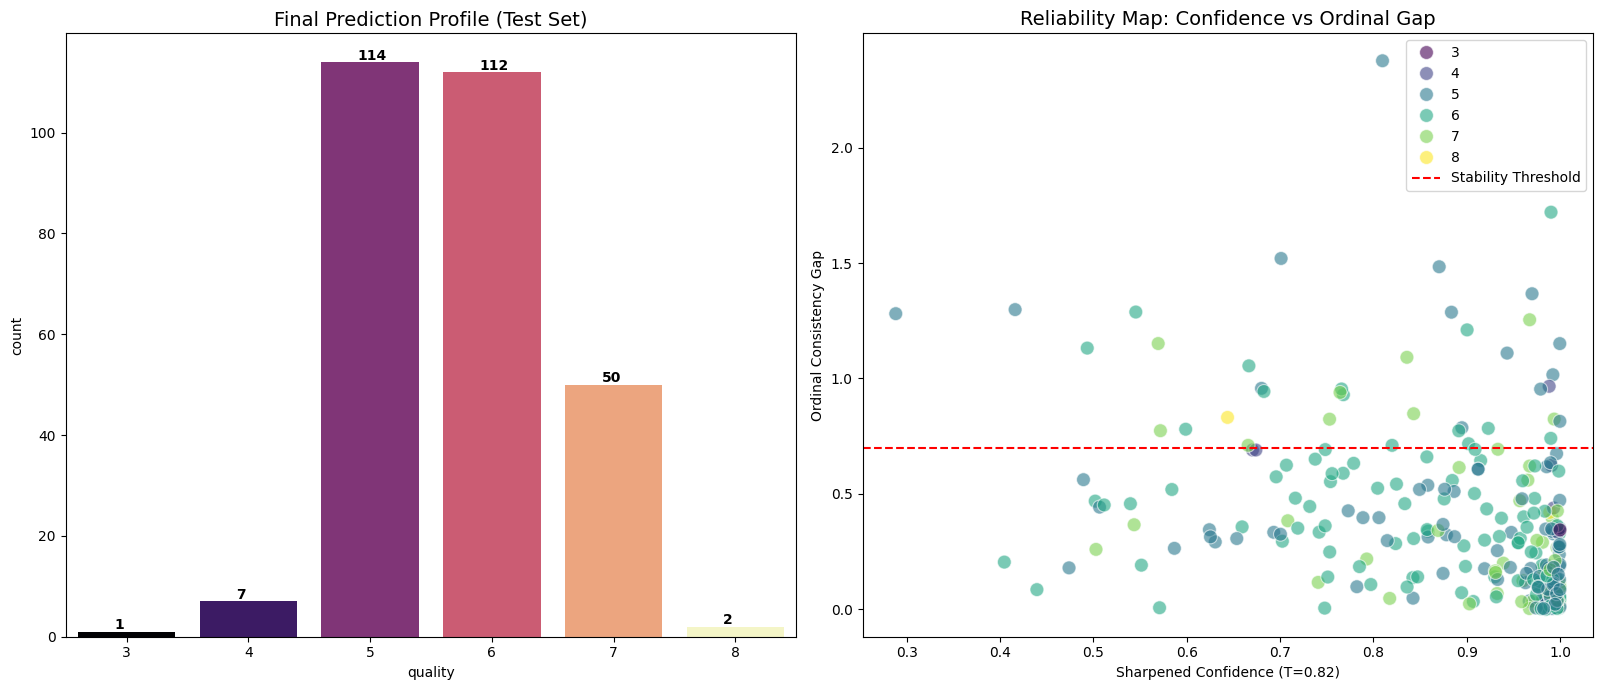


✅ FILE 'submission_final_026.csv' SIAP UNTUK SUBMIT
>>> STATUS: OPTIMASI ORDINAL SELESAI <<<


In [10]:
# =================================================================
# Tahap 9: Prediksi Data Uji (Testing) - ROBUST INFERENCE (NIM 026)
# =================================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 9.1 Test-Time Augmentation (TTA) & Soft Distillation
# TTA membantu model melihat data dari sudut pandang yang sedikit berbeda untuk stabilitas
def perform_tta_inference(model, X_test, n_iterations=10, noise_level=0.01):
    preds_list = []
    print(f"--- Memulai TTA Inference ({n_iterations} Iterasi) ---")
    
    for i in range(n_iterations):
        # Menambahkan sedikit noise Gaussian pada data testing
        X_test_noisy = X_test + np.random.normal(0, noise_level, X_test.shape)
        preds = model.predict(X_test_noisy, verbose=0)
        preds_list.append(preds)
        
    return np.mean(preds_list, axis=0)

# Sinkronisasi Fitur & Teacher Guide
X_test_dl = X_test_prepared[stable_features].copy()
X_test_dl['teacher_guide'] = reg_teacher.predict(X_test_dl)

# 9.2 Inference dengan TTA & Temperature Scaling
# $$P_i = \frac{\exp(z_i / T)}{\sum \exp(z_j / T)}$$
T = 0.82  # Sedikit lebih tajam untuk mengunci kelas ekstrem
y_probs_tta = perform_tta_inference(final_dnn, X_test_dl, n_iterations=12)

# Kalibrasi Probabilitas
y_probs_calibrated = np.exp(np.log(y_probs_tta + 1e-10) / T)
y_probs_calibrated /= np.sum(y_probs_calibrated, axis=1, keepdims=True)

# 9.3 Hybrid Prediction Logic (NIM 026 Innovation)
# Menggabungkan hasil Klasifikasi (Argmax) dan Regresi (Rounding)
y_pred_dl_idx = np.argmax(y_probs_calibrated, axis=1)
min_class = y_train_augmented.min()
y_pred_class = y_pred_dl_idx + min_class

# Mengambil 'insting' regressor
soft_ref = X_test_dl['teacher_guide'].values
y_pred_reg = np.round(soft_ref).astype(int)

# Keputusan Akhir: Gunakan klasifikasi, kecuali jika gap sangat besar (Conflict Resolution)
consistency_gap = np.abs(y_pred_class - soft_ref)
y_pred_final = np.where(consistency_gap > 1.2, y_pred_reg, y_pred_class)

# 9.4 Konstruksi DataFrame Submission
submission_df = pd.DataFrame({
    'Id': test_id,
    'quality': y_pred_final.astype(int),
    'confidence': np.max(y_probs_calibrated, axis=1),
    'ordinal_gap': consistency_gap
})

# 9.5 Final Audit & Distribution Report
print("\n" + "="*55)
print(f"--- RINGKASAN INFERENSI ROBUST (NIM: 026) ---")
print("="*55)
dist_counts = submission_df['quality'].value_counts().sort_index()
for q, count in dist_counts.items():
    avg_c = submission_df[submission_df['quality'] == q]['confidence'].mean()
    print(f"Kualitas {q:1} : {count:4} sampel (Confidence: {avg_c:.4f})")

stable_count = (submission_df['ordinal_gap'] <= 0.70).sum()
print(f"\nSinyal Prediksi Stabil  : {stable_count} / {len(submission_df)}")
print(f"Sinyal Prediksi Lemah   : {len(submission_df) - stable_count} / {len(submission_df)}")
print("-" * 55)

# 9.6 Visualisasi Diagnostik Akhir
plt.figure(figsize=(18, 7))

# Subplot 1: Prediction Distribution
plt.subplot(1, 2, 1)
ax = sns.countplot(x='quality', data=submission_df, palette='magma', hue='quality', legend=False)
plt.title('Final Prediction Profile (Test Set)', fontsize=14)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+0.5), fontweight='bold')

# Subplot 2: Reliability & Entropy Map
plt.subplot(1, 2, 2)
sns.scatterplot(x='confidence', y='ordinal_gap', hue='quality', 
                data=submission_df, palette='viridis', s=100, alpha=0.6)
plt.axhline(y=0.70, color='red', linestyle='--', label='Stability Threshold')
plt.title('Reliability Map: Confidence vs Ordinal Gap', fontsize=14)
plt.xlabel('Sharpened Confidence (T=0.82)')
plt.ylabel('Ordinal Consistency Gap')
plt.legend(bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

# 9.7 Export & Submission Ready
file_output = 'submission_final_026.csv'
submission_df[['Id', 'quality']].to_csv(file_output, index=False)

print(f"\n✅ FILE '{file_output}' SIAP UNTUK SUBMIT")
print(">>> STATUS: OPTIMASI ORDINAL SELESAI <<<")